In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [23]:
df = pd.read_parquet('../data/instacart_cleaned_v1.parquet')

In [24]:
df.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle,department
0,2,33120,1,1,202279,3,5,9,8.0,Organic Egg Whites,eggs,dairy eggs
1,2,28985,2,1,202279,3,5,9,8.0,Michigan Organic Kale,fresh vegetables,produce
2,2,9327,3,0,202279,3,5,9,8.0,Garlic Powder,spices seasonings,pantry
3,2,45918,4,1,202279,3,5,9,8.0,Coconut Butter,oils vinegars,pantry
4,2,30035,5,0,202279,3,5,9,8.0,Natural Sweetener,baking ingredients,pantry


In [25]:
import gc

# اقرأ من الـ parquet الأعمدة المطلوبة بس لبناء RFM
cols_needed = ['user_id', 'order_id', 'order_number', 
               'days_since_prior_order', 'product_id']

df = pd.read_parquet('../data/instacart_cleaned_v1.parquet', columns=cols_needed)

print(df.shape)
print(df.memory_usage(deep=True).sum() / 1e9, "GB")

(32434489, 5)
1.297379692 GB


In [26]:
# Recency + Frequency الأساسيين مع بعض في groupby واحد
rfm = df.groupby('user_id').agg(
    max_order_number=('order_number', 'max'),
    last_days_since_prior=('days_since_prior_order', 'last'),
    frequency=('order_id', 'nunique')
).reset_index()

print(rfm.shape)
rfm.head()

(206209, 4)


,user_id,max_order_number,last_days_since_prior,frequency
0,1,10,19.0,10
1,2,14,30.0,14
2,3,12,7.0,12
3,4,5,0.0,5
4,5,4,10.0,4


In [27]:
# حجم كل سلة (basket) لكل order_id
basket_sizes = df.groupby(['user_id', 'order_id'])['product_id'].count().reset_index()
basket_sizes.columns = ['user_id', 'order_id', 'basket_size']

# متوسط حجم السلة لكل يوزر
avg_basket = basket_sizes.groupby('user_id')['basket_size'].mean().reset_index()
avg_basket.columns = ['user_id', 'avg_basket_size']

print(avg_basket.shape)
avg_basket.head()

(206209, 2)


,user_id,avg_basket_size
0,1,5.900000
1,2,13.928571
2,3,7.333333
3,4,3.600000
4,5,9.250000


In [28]:
rfm_final = rfm.merge(avg_basket, on='user_id')

# نشيل max_order_number لأنها redundant مع frequency (زي ما اتفقنا)
rfm_final = rfm_final.drop(columns=['max_order_number'])

print(rfm_final.shape)
rfm_final.head()

(206209, 4)


,user_id,last_days_since_prior,frequency,avg_basket_size
0,1,19.0,10,5.900000
1,2,30.0,14,13.928571
2,3,7.0,12,7.333333
3,4,0.0,5,3.600000
4,5,10.0,4,9.250000


In [29]:
print(rfm_final.isnull().sum())
print("---")
print(f"نسبة الـ nulls: {rfm_final['last_days_since_prior'].isnull().mean() * 100:.2f}%")

user_id                  0
last_days_since_prior    0
frequency                0
avg_basket_size          0
dtype: int64
---
نسبة الـ nulls: 0.00%


In [30]:
from sklearn.preprocessing import StandardScaler

features = ['last_days_since_prior', 'frequency', 'avg_basket_size']
X = rfm_final[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])
print(X_scaled.mean(axis=0))  # المفروض قريب من 0
print(X_scaled.std(axis=0))   # المفروض قريب من 1

[[ 0.36499978 -0.33566236 -0.69097766]
 [ 1.43138495 -0.0954904   0.67825489]
 [-0.79832949 -0.21557638 -0.44652986]
 [-1.47693823 -0.63587732 -1.08323112]
 [-0.50749717 -0.69592031 -0.11965198]]
[-2.63254586e-17 -1.32316441e-17  3.66626806e-16]
[1. 1. 1.]


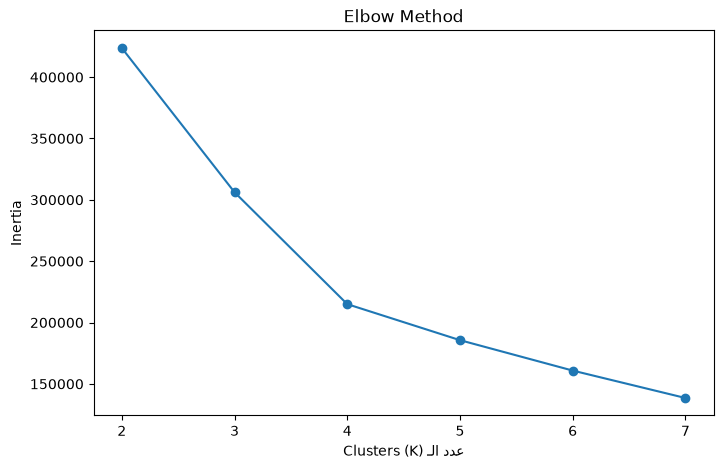

In [31]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('عدد الـ Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [32]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_final['cluster'] = kmeans_final.fit_predict(X_scaled)

print(rfm_final['cluster'].value_counts())
rfm_final.groupby('cluster')[features].mean()

cluster
3    84713
2    65044
1    34264
0    22188
Name: count, dtype: int64


,last_days_since_prior,frequency,avg_basket_size
cluster,,,
0,6.029250,54.571074,9.850368
1,15.168340,12.089161,19.565715
2,27.644979,8.179509,7.832806
3,8.144417,12.486867,7.716289


In [36]:
cluster_names = {
    0: 'VIP / Power Users',
    1: 'Bulk Buyers',
    2: 'At Risk / Dormant',
    3: 'Regular Customers'
}

rfm_final['cluster_name'] = rfm_final['cluster'].map(cluster_names)

rfm_final.groupby('cluster_name')[['last_days_since_prior', 'frequency', 'avg_basket_size']].mean()

,last_days_since_prior,frequency,avg_basket_size
cluster_name,,,
At Risk / Dormant,27.644979,8.179509,7.832806
Bulk Buyers,15.168340,12.089161,19.565715
Regular Customers,8.144417,12.486867,7.716289
VIP / Power Users,6.029250,54.571074,9.850368


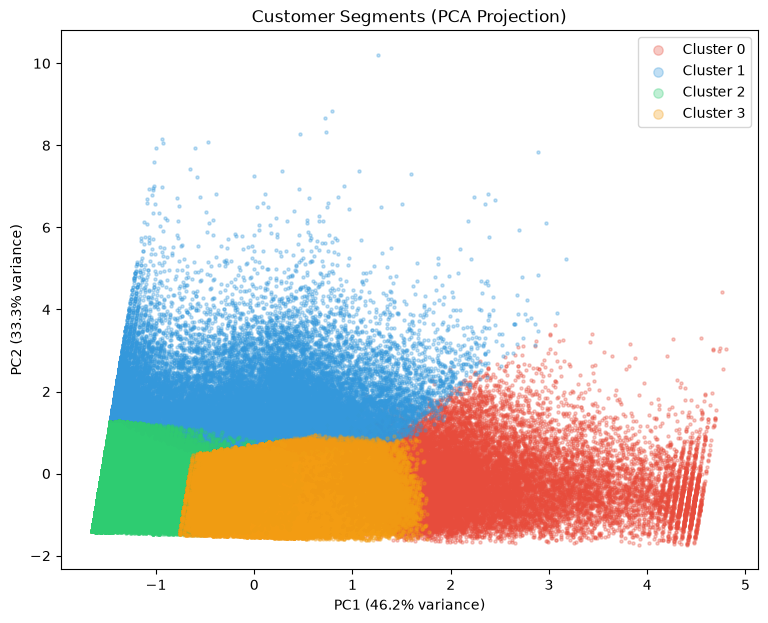

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
for cluster_id in sorted(rfm_final['cluster'].unique()):
    mask = rfm_final['cluster'] == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               s=5, alpha=0.3, 
               color=colors[cluster_id], 
               label=f'Cluster {cluster_id}')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Customer Segments (PCA Projection)')
plt.legend(markerscale=3)
plt.show()

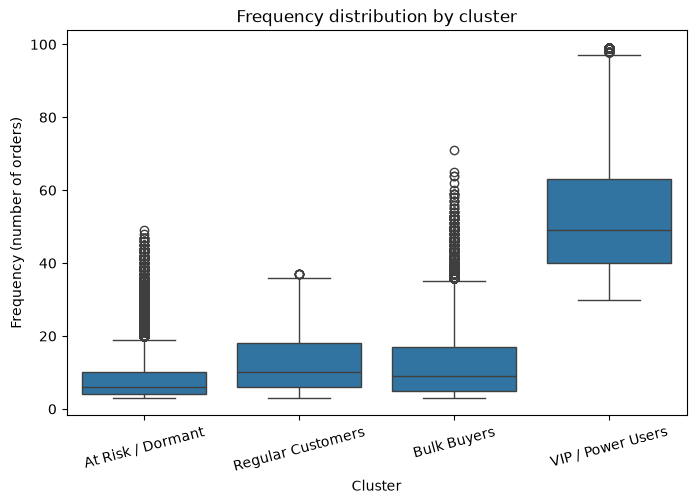

             cluster  n_users  n_outliers  pct_outliers  lower_bound  \
0  At Risk / Dormant    65044        3863          5.94         -5.0   
1        Bulk Buyers    34264         858          2.50        -13.0   
2  Regular Customers    84713           6          0.01        -12.0   
3  VIP / Power Users    22188        1421          6.40          5.5   

   upper_bound  max_value  
0         19.0         49  
1         35.0         71  
2         36.0         37  
3         97.5         99  


In [37]:
# 1. الرسمة
plt.figure(figsize=(8, 5))
sns.boxplot(data=rfm_final, x='cluster_name', y='frequency')
plt.title('Frequency distribution by cluster')
plt.xlabel('Cluster')
plt.ylabel('Frequency (number of orders)')
plt.xticks(rotation=15)
plt.show()

# 2. حساب outliers فعليًا بمعيار IQR لكل cluster لوحده
def get_outliers_iqr(df, group_col, value_col):
    results = []
    for cluster_id, group in df.groupby(group_col):
        Q1 = group[value_col].quantile(0.25)
        Q3 = group[value_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = group[(group[value_col] < lower_bound) | (group[value_col] > upper_bound)]
        results.append({
            'cluster': cluster_id,
            'n_users': len(group),
            'n_outliers': len(outliers),
            'pct_outliers': round(len(outliers) / len(group) * 100, 2),
            'lower_bound': round(lower_bound, 2),
            'upper_bound': round(upper_bound, 2),
            'max_value': group[value_col].max()
        })
    return pd.DataFrame(results)

outlier_summary = get_outliers_iqr(rfm_final, 'cluster_name', 'frequency')
print(outlier_summary)

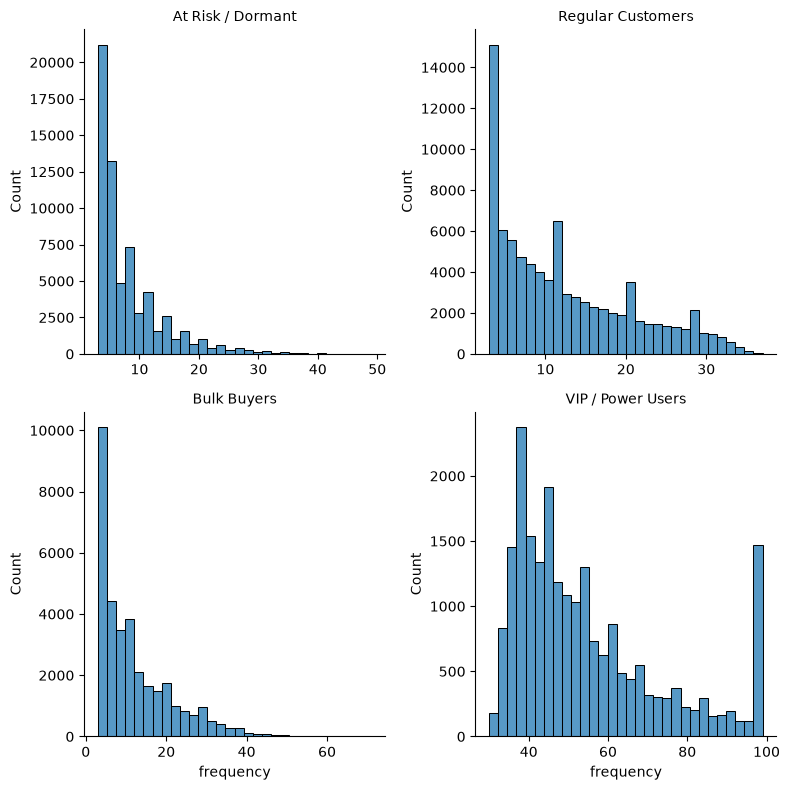

In [38]:
g = sns.FacetGrid(rfm_final, col='cluster_name', col_wrap=2, sharex=False, sharey=False, height=4)
g.map(sns.histplot, 'frequency', bins=30)
g.set_titles('{col_name}')
plt.tight_layout()
plt.show()

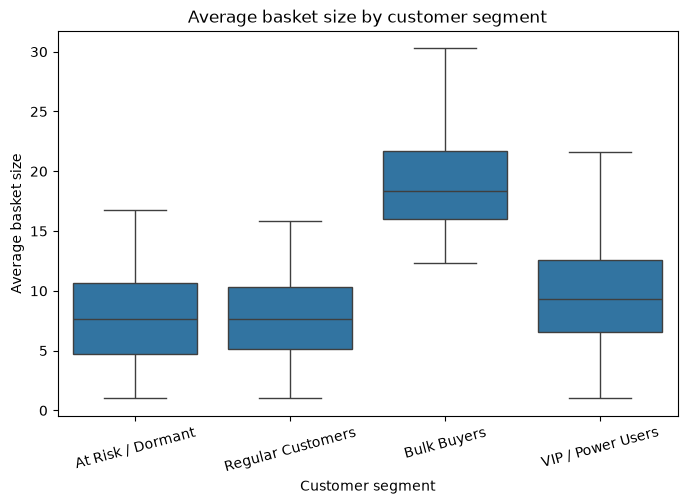

In [39]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=rfm_final, x='cluster_name', y='avg_basket_size', showfliers=False)
plt.title('Average basket size by customer segment')
plt.xlabel('Customer segment')
plt.ylabel('Average basket size')
plt.xticks(rotation=15)
plt.show()

In [41]:
import os
os.makedirs('../data/processed', exist_ok=True)

rfm_final['pca1'] = X_pca[:, 0]
rfm_final['pca2'] = X_pca[:, 1]

rfm_final.to_parquet('../data/processed/segments.parquet', index=False)
print("✅ saved segments.parquet (with pca1, pca2)", rfm_final.shape)

✅ saved segments.parquet (with pca1, pca2) (206209, 8)
